# Quick RF Experiments (Subject-Level Aggregation)
Aggregates features per subject first, then runs RF with different configs.  
Each experiment takes seconds, not hours.

---

In [1]:
CYMO_CSV = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_CSV = './cymo_parkceleb_per_recording_metadata.csv'
FEAT_CSV = './mrmr_top10_features.csv'  # swap in different feature files to compare

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, auc
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titleweight': 'bold'})

In [3]:
# Load and aggregate to subject level
cymo = pd.read_csv(CYMO_CSV)
meta = pd.read_csv(META_CSV)
features = pd.read_csv(FEAT_CSV)['feature'].tolist()

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]

df = cymo.merge(meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
                left_on=tid_col, right_on=meta_tid, how='inner')
df['label'] = (df['group'] == 'PD').astype(int)
for col in features:
    df[col] = pd.to_numeric(df.get(col, 0), errors='coerce')
df[features] = df[features].fillna(df[features].median())

# Aggregate: mean + std per subject
agg = {f: ['mean', 'std'] for f in features}
agg['label'] = 'first'
subj = df.groupby('subject').agg(agg).reset_index()
subj.columns = ['subject'] + [f'{a}_{b}' if b else a for a, b in subj.columns[1:]]
label_col = [c for c in subj.columns if 'label' in c][0]
subj = subj.rename(columns={label_col: 'label'}).fillna(0)
feat_cols = [c for c in subj.columns if c not in ('subject', 'label')]

print(f'{len(subj)} subjects, {len(feat_cols)} features (mean+std)')
print(f'CN: {(subj["label"]==0).sum()}  PD: {(subj["label"]==1).sum()}')

100 subjects, 48 features (mean+std)
CN: 60  PD: 40


In [4]:
# ============================================================
# Run 20 random splits × parameter configs
# ============================================================
N_SPLITS = 20

# ╔══════════════════════════════════════════════════════════╗
# ║  ADJUST THESE to experiment                             ║
# ╚══════════════════════════════════════════════════════════╝
rf_configs = [
    {'n': 100, 'd': 3,    'ml': 3, 'mf': 'sqrt'},
    {'n': 100, 'd': 5,    'ml': 3, 'mf': 'sqrt'},
    {'n': 200, 'd': 5,    'ml': 3, 'mf': 'sqrt'},
    {'n': 200, 'd': 5,    'ml': 5, 'mf': 'sqrt'},
    {'n': 200, 'd': 10,   'ml': 3, 'mf': 'sqrt'},
    {'n': 200, 'd': None, 'ml': 3, 'mf': 'sqrt'},
    {'n': 500, 'd': 5,    'ml': 3, 'mf': 'sqrt'},
    {'n': 500, 'd': 10,   'ml': 5, 'mf': 'sqrt'},
    {'n': 200, 'd': 5,    'ml': 3, 'mf': 'log2'},
    {'n': 200, 'd': 5,    'ml': 3, 'mf': None},   # use all features per split
]

results = []
for cfg in rf_configs:
    for seed in range(N_SPLITS):
        np.random.seed(seed)
        cn = subj[subj['label']==0].sample(frac=1, random_state=seed)
        pd_g = subj[subj['label']==1].sample(frac=1, random_state=seed)
        cs, ps = int(len(cn)*0.7), int(len(pd_g)*0.7)
        train = pd.concat([cn.iloc[:cs], pd_g.iloc[:ps]])
        test = pd.concat([cn.iloc[cs:], pd_g.iloc[ps:]])

        sc = StandardScaler()
        X_tr = sc.fit_transform(train[feat_cols].values)
        X_te = sc.transform(test[feat_cols].values)

        rf = RandomForestClassifier(
            n_estimators=cfg['n'], max_depth=cfg['d'],
            min_samples_leaf=cfg['ml'], max_features=cfg['mf'],
            class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_tr, train['label'].values)
        y_prob = rf.predict_proba(X_te)[:, 1]
        y_pred = rf.predict(X_te)
        y_te = test['label'].values

        results.append({
            **cfg, 'seed': seed,
            'acc': accuracy_score(y_te, y_pred),
            'auc': roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5,
            'f1': f1_score(y_te, y_pred, zero_division=0),
        })

res_df = pd.DataFrame(results)
print(f'Done: {len(res_df)} experiments')

Done: 200 experiments


In [5]:
# Summary
res_df['config'] = res_df.apply(lambda r: f"n={r['n']} d={r['d']} ml={r['ml']} mf={r['mf']}", axis=1)
summary = res_df.groupby('config').agg(
    acc=('acc', 'mean'), acc_std=('acc', 'std'),
    auc=('auc', 'mean'), auc_std=('auc', 'std'),
    f1=('f1', 'mean'),
).sort_values('auc', ascending=False).round(3)

print(f'{"Config":<40s} {"Acc":>12s} {"AUC":>12s} {"F1":>6s}')
print('─' * 75)
for cfg, r in summary.iterrows():
    print(f'{cfg:<40s} {r["acc"]:.3f}±{r["acc_std"]:.3f} {r["auc"]:.3f}±{r["auc_std"]:.3f} {r["f1"]:.3f}')

Config                                            Acc          AUC     F1
───────────────────────────────────────────────────────────────────────────
n=200 d=5.0 ml=3 mf=nan                  0.803±0.064 0.865±0.062 0.756
n=500 d=5.0 ml=3 mf=sqrt                 0.818±0.050 0.864±0.068 0.770
n=200 d=nan ml=3 mf=sqrt                 0.822±0.047 0.863±0.065 0.776
n=200 d=10.0 ml=3 mf=sqrt                0.822±0.047 0.863±0.065 0.776
n=200 d=5.0 ml=3 mf=sqrt                 0.823±0.048 0.863±0.065 0.778
n=200 d=5.0 ml=3 mf=log2                 0.810±0.061 0.859±0.070 0.760
n=100 d=3.0 ml=3 mf=sqrt                 0.810±0.051 0.856±0.063 0.765
n=100 d=5.0 ml=3 mf=sqrt                 0.818±0.046 0.856±0.066 0.774
n=500 d=10.0 ml=5 mf=sqrt                0.810±0.048 0.852±0.065 0.759
n=200 d=5.0 ml=5 mf=sqrt                 0.810±0.047 0.849±0.066 0.763


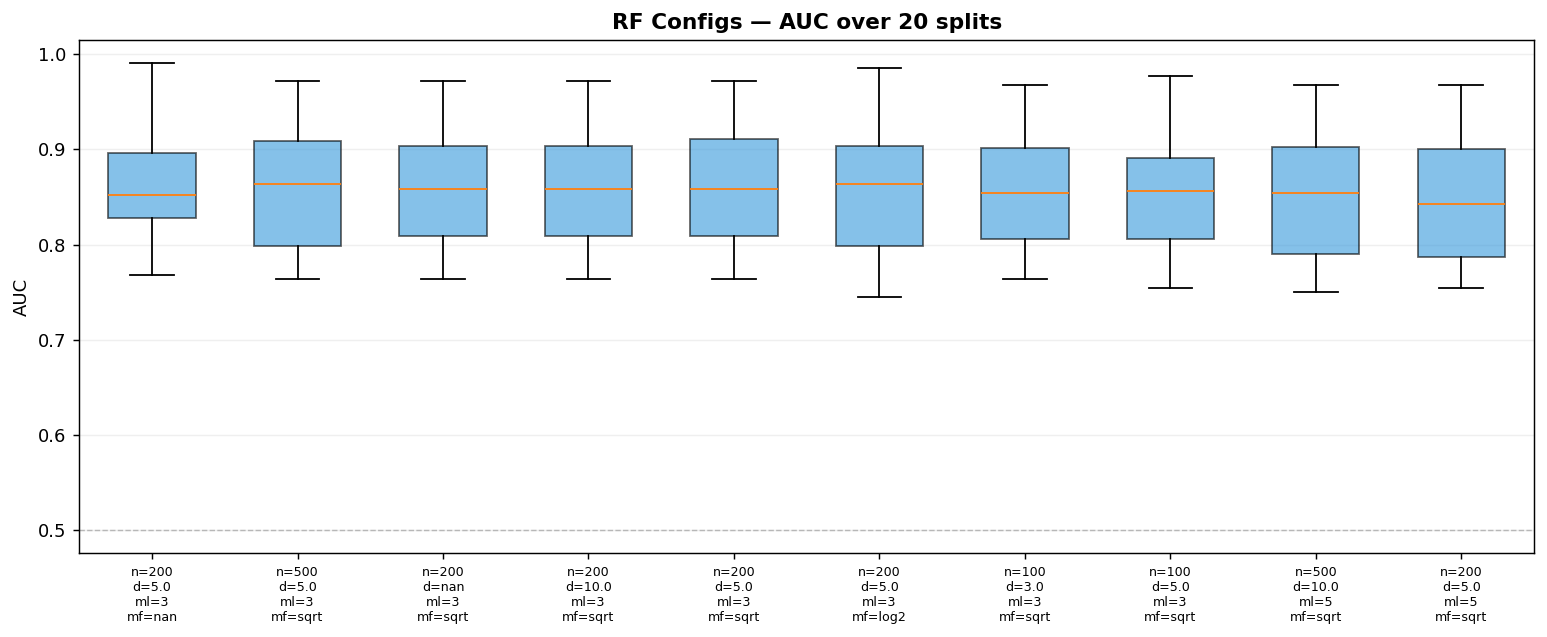

In [6]:
# Box plot
fig, ax = plt.subplots(figsize=(12, 5))
order = summary.index.tolist()
data = [res_df[res_df['config']==c]['auc'].values for c in order]
bp = ax.boxplot(data, labels=[c.replace(' ', '\n') for c in order], patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor('#3498DB'); patch.set_alpha(0.6)
ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.set_ylabel('AUC'); ax.set_title(f'RF Configs — AUC over {N_SPLITS} splits')
ax.tick_params(axis='x', labelsize=7); ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.savefig('rf_quick_comparison.png', dpi=150, bbox_inches='tight'); plt.show()